<a href="https://colab.research.google.com/github/Parker-P-Wilson/Linear-regression/blob/tuan-4/Lab_4_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bai mau**


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import Input

import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Path to dataset files: /kaggle/input/mnist-in-csv


In [ ]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(19999, 785)
(19999, 784)
(19999,)
(9999, 784)
(9999,)


In [ ]:
num_classes = 10
input_shape = (28,28,1)
X_train = X_train.astype("float32")/225
X_test = X_test.astype("float32")/225
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0],28,28,1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0],28,28,1)
print(X_test.shape)

(19999, 28, 28, 1)
(9999, 28, 28, 1)


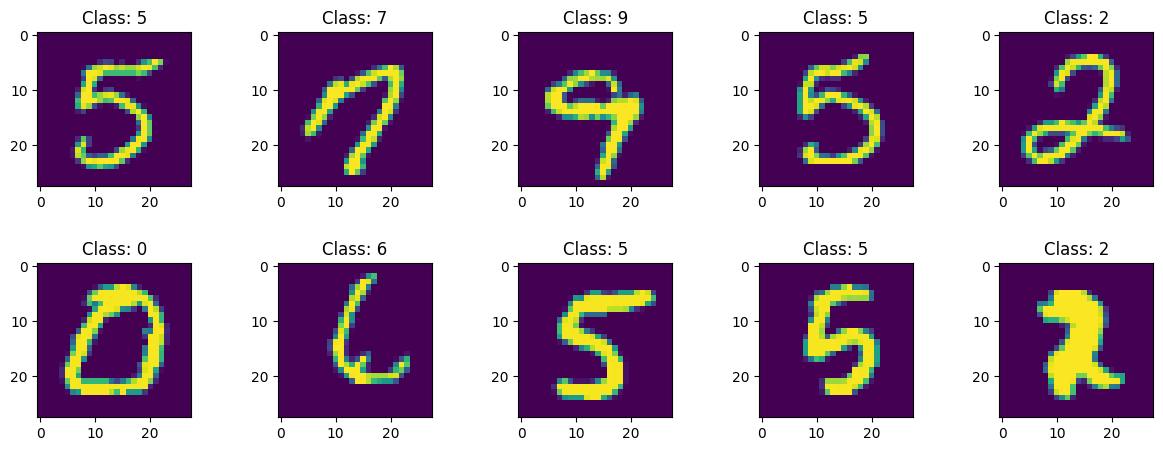

In [ ]:
fig, axes = plt.subplots(nrows= 2, ncols = 5, figsize = (15,5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class: '+str(y_train[i]))
plt.subplots_adjust(hspace= 0.5)
plt.show()

In [ ]:
Y_train = keras.utils.to_categorical(y_train, num_classes)
Y_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
model = Sequential()

model.add(Input(shape=input_shape))

# Block 1
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))          # Dropout sau pooling

# Block 2
model.add(Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))          # Dropout sau pooling

# Fully Connected
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))           # Dropout mạnh hơn ở FC layer
model.add(Dense(units=10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,538 (1.61 MB)

 Trainable params: 422,090 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/50
562/563 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8013 - loss: 0.6470
Epoch 1: val_loss improved from None to 0.28735, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.8914 - loss: 0.3546 - val_accuracy: 0.9175 - val_loss: 0.2873
Epoch 2/50
562/563 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9555 - loss: 0.1521
Epoch 2: val_loss improved from 0.28735 to 0.07575, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 38s 67ms/step - accuracy: 0.9581 - loss: 0.1418 - val_accuracy: 0.9765 - val_loss: 0.0758
Epoch 3/50
562/563 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9682 - loss: 0.1065
Epoch 3: val_loss improved from 0.07575 to 0.06339, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 36s 63ms/step - accuracy: 0.9668 - loss: 0.1079 - val_accuracy: 

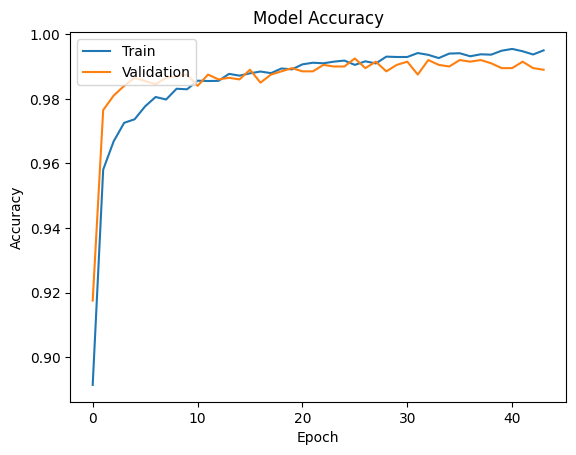

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

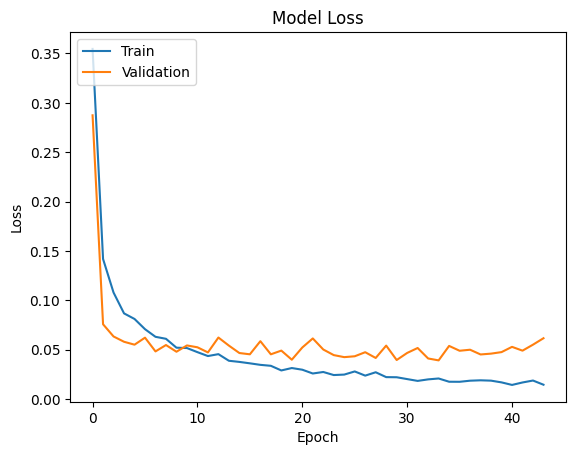

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [ ]:
score = model.evaluate(X_test, Y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 5s - 15ms/step - accuracy: 0.9922 - loss: 0.0289
Test loss: 0.028867650777101517
Test accuracy: 0.9921992421150208


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[3.2820190e-06 2.8305254e-05 9.9996805e-01 7.3562330e-09 9.0070945e-10
  1.2573166e-11 2.4533327e-07 8.4384150e-10 2.6316838e-10 1.1698113e-10]]
2 0


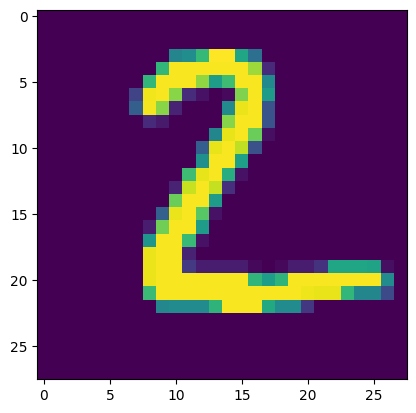

In [ ]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


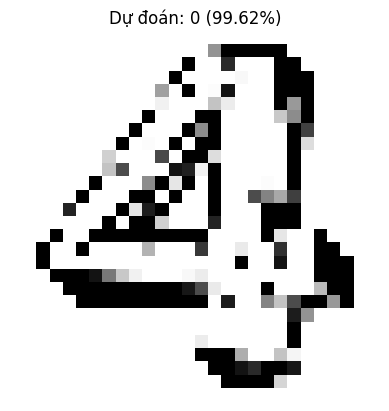

Dự đoán: 0
Độ tin cậy: 99.62%
Xác suất tất cả các class:
  0: 99.62%
  1: 0.00%
  2: 0.00%
  3: 0.00%
  4: 0.00%
  5: 0.00%
  6: 0.00%
  7: 0.00%
  8: 0.00%
  9: 0.38%


In [ ]:
# predict anh that
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# ── LOAD & PREPROCESS ────────────────────────────────────────────────────────
img_path = '/content/images.png'  # đường dẫn ảnh thật

img = image.load_img(img_path, color_mode='grayscale', target_size=(28, 28))
img_array = image.img_to_array(img) / 255.0       # normalize [0, 1]
img_array = np.expand_dims(img_array, axis=0)     # shape: (1, 28, 28, 1)
img_array = 1 - img_array

# ── PREDICT ──────────────────────────────────────────────────────────────────
predict = model.predict(img_array)
predicted_class = np.argmax(predict)
confidence = np.max(predict) * 100

# ── HIỂN THỊ ─────────────────────────────────────────────────────────────────
plt.imshow(img, cmap='gray')
plt.title(f'Dự đoán: {class_names[predicted_class]} ({confidence:.2f}%)')
plt.axis('off')
plt.show()

print(f'Dự đoán: {class_names[predicted_class]}')
print(f'Độ tin cậy: {confidence:.2f}%')
print(f'Xác suất tất cả các class:')
for i, prob in enumerate(predict[0]):
    print(f'  {class_names[i]}: {prob*100:.2f}%')

In [ ]:
model.save_weights('cnn.weights.h5')

In [ ]:
from tensorflow.keras.models import load_model
best_model = load_model('best_model.keras')

In [ ]:
model = Sequential()

model.add(Input(shape=input_shape))

# Block 1
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))          # Dropout sau pooling

# Block 2
model.add(Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))          # Dropout sau pooling

# Fully Connected
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))           # Dropout mạnh hơn ở FC layer
model.add(Dense(units=10, activation='softmax'))

model.load_weight('cnn.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.agrmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()


AttributeError: 'Sequential' object has no attribute 'load_weight'

**Bai 1**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom


In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()

X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

Y_train = Y_train.flatten()
Y_test = Y_test.flatten()

print(X_train.shape)
print(y_train.shape)


(50000, 32, 32, 3)
(50000,)


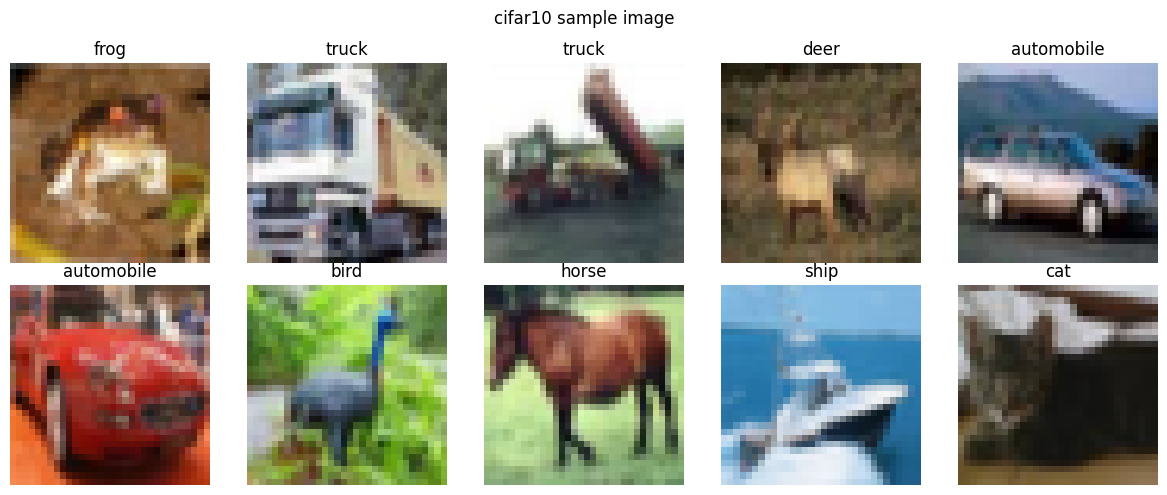

In [ ]:
y_train = y_train.flatten()
y_test  = y_test.flatten()
fig, axes = plt.subplots(nrows= 2, ncols = 5, figsize = (12,5))
for i, ax in enumerate(axes.flat):
  ax.imshow(X_train[i])
  ax.set_title(class_names[y_train[i]])
  ax.axis('off')
plt.suptitle('cifar10 sample image')
plt.tight_layout()
plt.show()

In [ ]:
# Giảm L2 và tiếp tục train thêm
model = Sequential()
model.add(Input(shape=(32, 32, 3)))

model.add(RandomFlip('horizontal'))
model.add(RandomRotation(0.1))
model.add(RandomZoom(0.1))

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same',
                 kernel_regularizer=l2(1e-5)))   # giảm từ 1e-4 → 1e-5
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu', padding='same',
                 kernel_regularizer=l2(1e-5)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same',
                 kernel_regularizer=l2(1e-5)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu', padding='same',
                 kernel_regularizer=l2(1e-5)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))
model.add(Dropout(0.35))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same',
                 kernel_regularizer=l2(1e-5)))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu', padding='same',
                 kernel_regularizer=l2(1e-5)))  # thêm 1 conv nữa
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))
model.add(Dropout(0.4))

# Fully Connected
model.add(Flatten())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(1e-5)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))


model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_cifar10.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/150
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3120 - loss: 2.2323
Epoch 1: val_loss improved from None to 1.56479, saving model to best_cifar10.keras

Epoch 1: finished saving model to best_cifar10.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.3792 - loss: 1.8698 - val_accuracy: 0.4682 - val_loss: 1.5648 - learning_rate: 0.0010
Epoch 2/150
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4959 - loss: 1.4246
Epoch 2: val_loss improved from 1.56479 to 1.41920, saving model to best_cifar10.keras

Epoch 2: finished saving model to best_cifar10.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.5139 - loss: 1.3672 - val_accuracy: 0.4928 - val_loss: 1.4192 - learning_rate: 0.0010
Epoch 3/150
702/704 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5526 - loss: 1.2639
Epoch 3: val_loss improved from 1.41920 to 1.30305, saving model to best_cifar10.keras

Epoch 3: finished saving model to best_cifar10.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest loss:     {score[0]:.4f}')
print(f'Test accuracy: {score[1]:.4f}')

313/313 - 2s - 6ms/step - accuracy: 0.8532 - loss: 0.5162

Test loss:     0.5162
Test accuracy: 0.8532


313/313 - 2s - 5ms/step - accuracy: 0.8532 - loss: 0.5162

Test loss:     0.5162
Test accuracy: 0.8532


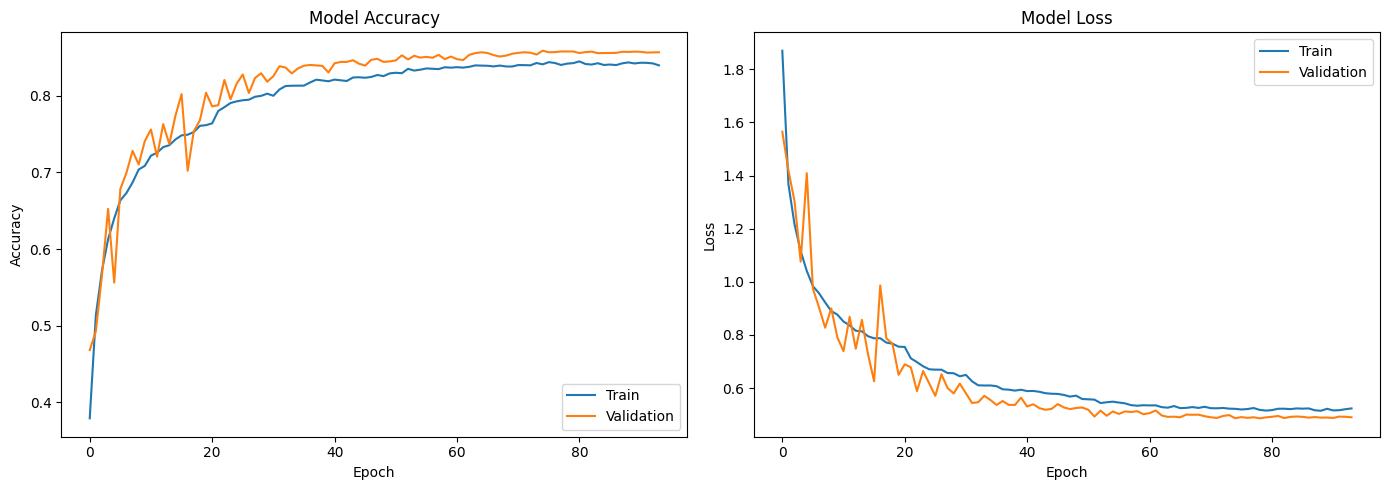

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest loss:     {score[0]:.4f}')
print(f'Test accuracy: {score[1]:.4f}')

# ── PLOT ACCURACY & LOSS ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='lower right')

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


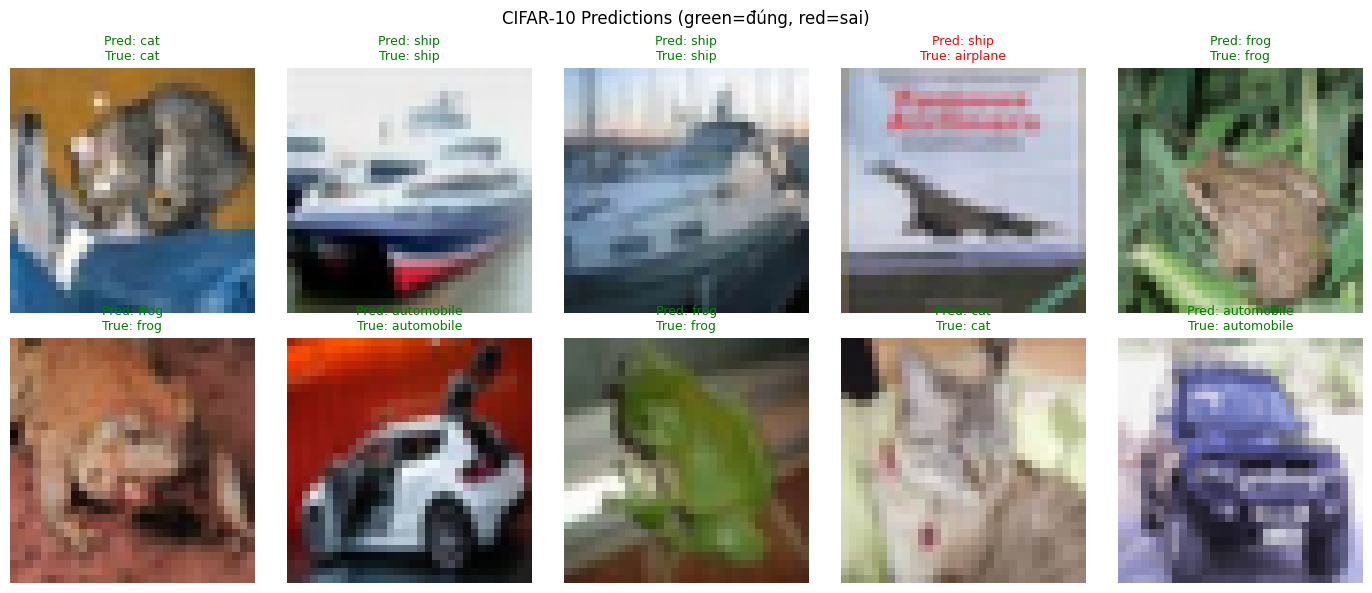

In [ ]:
predictions = model.predict(X_test[:10])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i])
    pred  = class_names[np.argmax(predictions[i])]
    truth = class_names[y_test[i]]
    color = 'green' if pred == truth else 'red'
    ax.set_title(f'Pred: {pred}\nTrue: {truth}', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 Predictions (green=đúng, red=sai)')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step


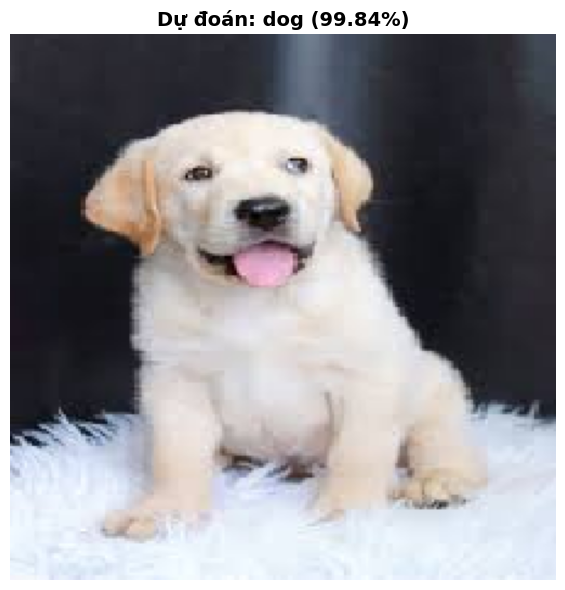


Dự đoán: dog
Độ tin cậy: 99.84%

Xác suất tất cả các class:
  dog         :  99.84%  █████████████████████████████
  cat         :   0.13%  
  bird        :   0.01%  
  horse       :   0.01%  
  frog        :   0.00%  
  ship        :   0.00%  
  deer        :   0.00%  
  airplane    :   0.00%  
  truck       :   0.00%  
  automobile  :   0.00%  


In [ ]:

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def predict_image(img_path):

    img = image.load_img(img_path, target_size=(32, 32))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)


    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    img_display = image.load_img(img_path, target_size=(224, 224))

    plt.figure(figsize=(6, 6))
    plt.imshow(img_display)
    plt.title(f'Dự đoán: {class_names[predicted_class]} ({confidence:.2f}%)',
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # In xác suất tất cả các class
    print(f'\nDự đoán: {class_names[predicted_class]}')
    print(f'Độ tin cậy: {confidence:.2f}%')
    print('\nXác suất tất cả các class:')
    sorted_idx = np.argsort(predictions[0])[::-1]
    for i in sorted_idx:
        bar = '█' * int(predictions[0][i] * 30)
        print(f'  {class_names[i]:12s}: {predictions[0][i]*100:6.2f}%  {bar}')

# ── SỬ DỤNG ──────────────────────────────────────────────────────────────────
predict_image('/content/images (2).jpg')

**Bai 3**